In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import DBSCAN, KMeans, AgglomerativeClustering
from sklearn.mixture import GaussianMixture
from sklearn.cluster import KMeans
from sklearn.cluster import AgglomerativeClustering
from scipy.cluster import hierarchy
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score, silhouette_samples
np.random.seed(42)


In [2]:
df = pd.read_csv("/Users/vishnu/Documents/Documents - Mac/CSE(AI&ML)/SIC Sem-7/DJ/store_customers.csv")
features = ['Annual Income (k$)', 'Spending Score (1-100)']
data = df[features].copy()
data = data.dropna()
print(data.head())


   Annual Income (k$)  Spending Score (1-100)
0                59.9                    58.0
1                48.4                    37.0
2                70.5                    26.0
3                81.1                    30.0
4                42.1                    58.0


### DBSCAN

In [3]:
scaler = StandardScaler()
data_scaled = scaler.fit_transform(data)
db = DBSCAN(eps=0.2,min_samples=5)
labels = db.fit_predict(data_scaled)
data['Cluster'] = labels

In [4]:
data.head()

,Annual Income (k$),Spending Score (1-100),Cluster
0,59.9,58.0,0
1,48.4,37.0,0
2,70.5,26.0,0
3,81.1,30.0,0
4,42.1,58.0,0


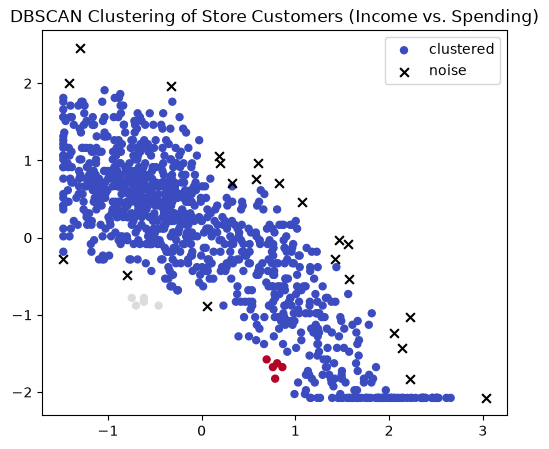

In [5]:
plt.figure(figsize=(6, 5))
noise_mask = labels == -1
plt.scatter(data_scaled[~noise_mask, 0], data_scaled[~noise_mask, 1], c=labels[~noise_mask], cmap="coolwarm", s=25, label="clustered")
plt.scatter(data_scaled[noise_mask, 0], data_scaled[noise_mask, 1], c="black", marker="x", s=40, label="noise")
plt.legend()
plt.title("DBSCAN Clustering of Store Customers (Income vs. Spending)")
plt.show()

In [6]:
min_samples = 5
neighbors = NearestNeighbors(n_neighbors=min_samples).fit(data_scaled)
distances,_ = neighbors.kneighbors(data_scaled)
k_distances = np.sort(distances[:,-1])

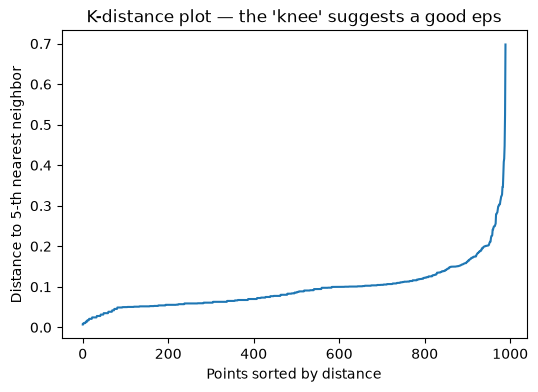

In [7]:
plt.figure(figsize=(6, 4))
plt.plot(k_distances)
plt.xlabel("Points sorted by distance")
plt.ylabel(f"Distance to {min_samples}-th nearest neighbor")
plt.title("K-distance plot — the 'knee' suggests a good eps")
plt.show()


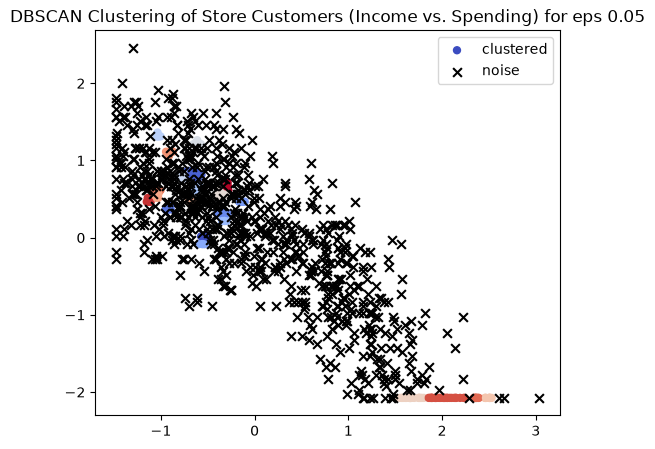

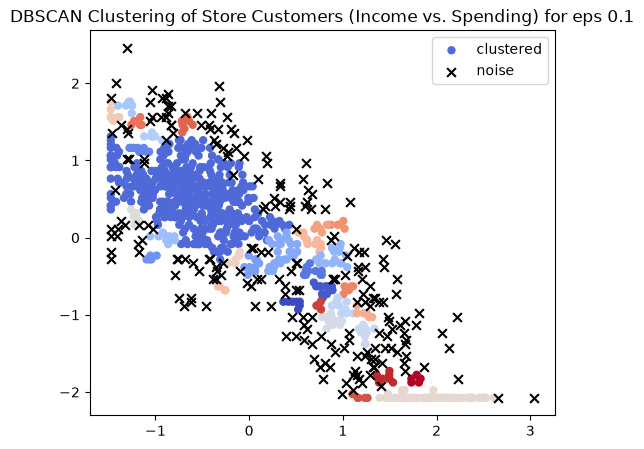

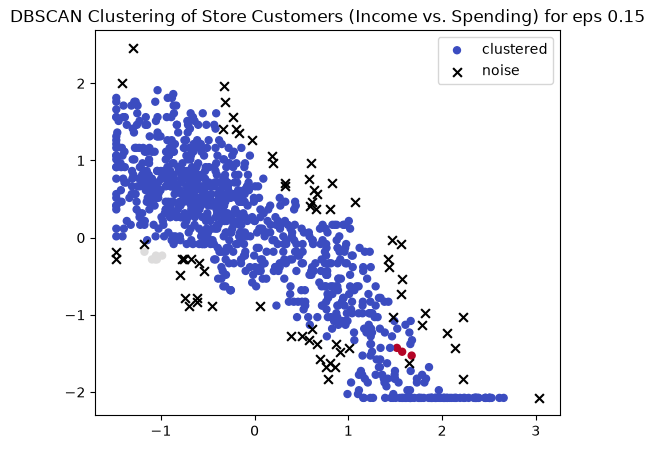

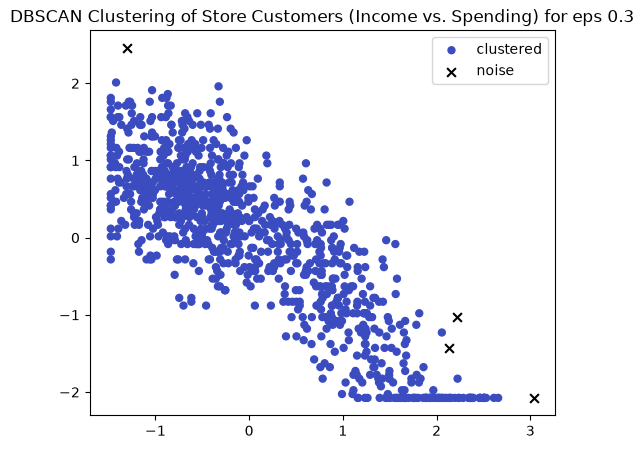

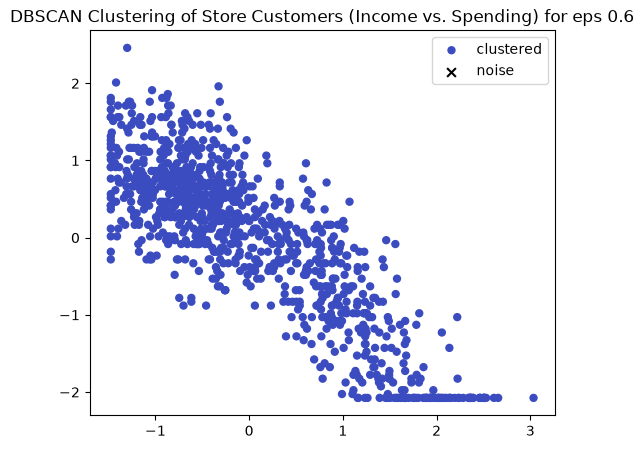

In [8]:
for eps in [0.05,0.1, 0.15, 0.3,0.6]:
    db = DBSCAN(eps,min_samples=5)
    labels = db.fit_predict(data_scaled)
    data['Cluster'] = labels
    plt.figure(figsize=(6, 5))
    noise_mask = labels == -1
    plt.scatter(data_scaled[~noise_mask, 0], data_scaled[~noise_mask, 1], c=labels[~noise_mask], cmap="coolwarm", s=25, label="clustered")
    plt.scatter(data_scaled[noise_mask, 0], data_scaled[noise_mask, 1], c="black", marker="x", s=40, label="noise")
    plt.legend()
    plt.title(f"DBSCAN Clustering of Store Customers (Income vs. Spending) for eps {eps}")
    plt.show()

### GMM

In [9]:
gmm = GaussianMixture(n_components=3,random_state=42)
gmm.fit(data_scaled)
hard_labels = gmm.predict(data_scaled)
probs = gmm.predict_proba(data_scaled)
print("Probabilities for the first 5 points (rows sum to 1):")
print(np.round(probs[:5], 3))

Probabilities for the first 5 points (rows sum to 1):
[[0.    0.602 0.398]
 [0.    0.95  0.05 ]
 [0.    0.04  0.96 ]
 [0.    0.003 0.997]
 [0.    0.981 0.019]]


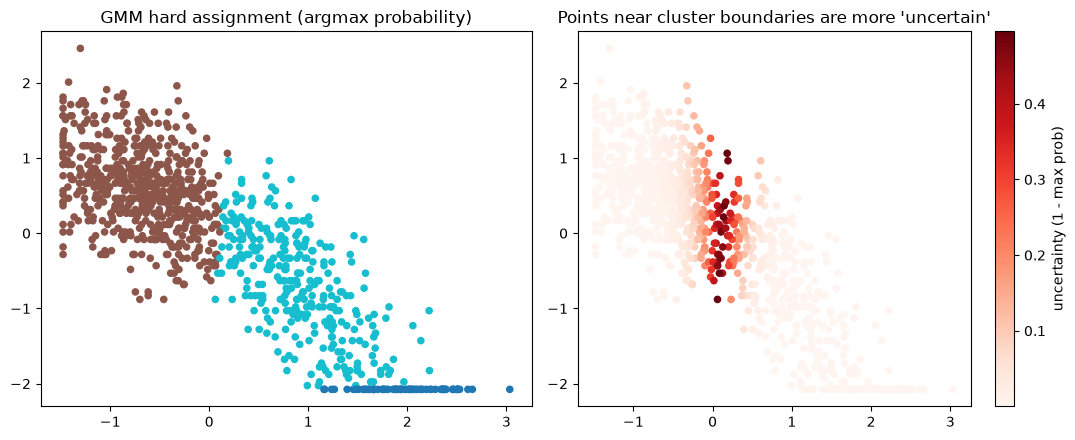

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
axes[0].scatter(data_scaled[:, 0], data_scaled[:, 1], c=hard_labels, cmap="tab10", s=20)
axes[0].set_title("GMM hard assignment (argmax probability)")

# Color by max probability -> shows uncertainty near cluster boundaries
uncertainty = 1 - probs.max(axis=1)
sc = axes[1].scatter(data_scaled[:, 0], data_scaled[:, 1], c=uncertainty, cmap="Reds", s=20)
plt.colorbar(sc, ax=axes[1], label="uncertainty (1 - max prob)")
axes[1].set_title("Points near cluster boundaries are more 'uncertain'")
plt.tight_layout()
plt.show()

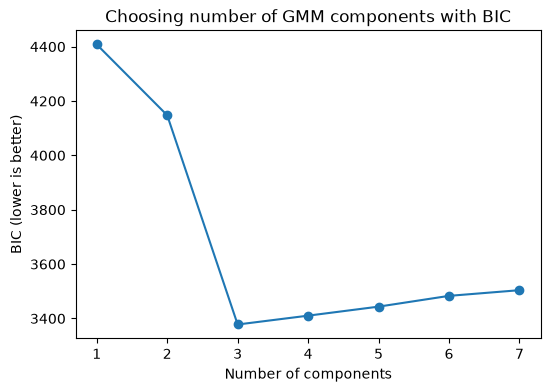

In [11]:
bics = []
comps = range(1, 8)
for n in comps:
    g = GaussianMixture(n_components=n, random_state=42).fit(data_scaled)
    bics.append(g.bic(data_scaled))

plt.figure(figsize=(6, 4))
plt.plot(list(comps), bics, marker="o")
plt.xlabel("Number of components"); plt.ylabel("BIC (lower is better)")
plt.title("Choosing number of GMM components with BIC")
plt.show()


### Agglomerative

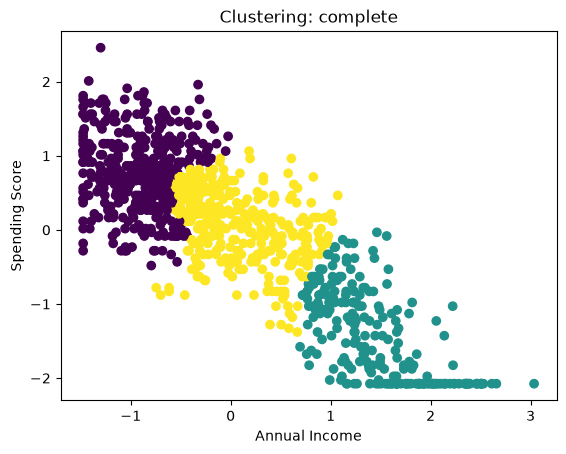

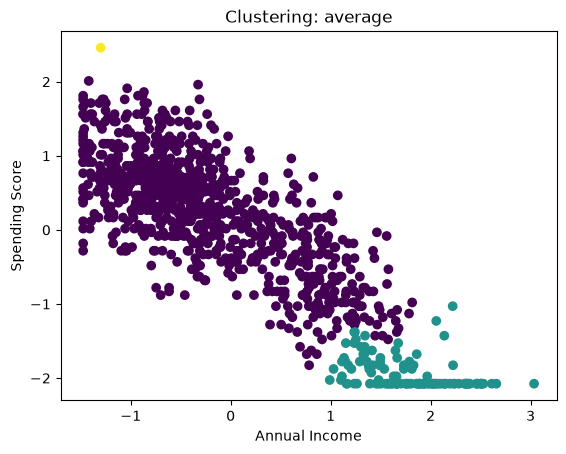

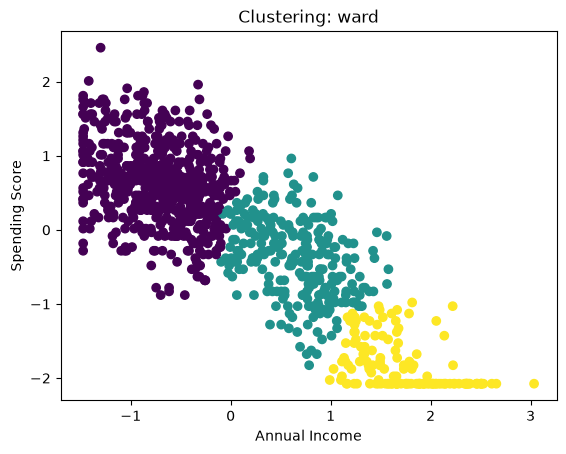

In [12]:
linkage = ["complete","average","ward"]
for idx , i in enumerate(linkage) :
        plt.figure (idx)
        hier = AgglomerativeClustering(n_clusters=3,metric="euclidean",linkage=i)
        hier.fit(data_scaled)
        plt.scatter(data_scaled[:,0],data_scaled[:,1],c=hier.labels_)
        plt.title("Clustering: "+i)
        plt.xlabel('Annual Income')
        plt.ylabel('Spending Score')
        plt.show()

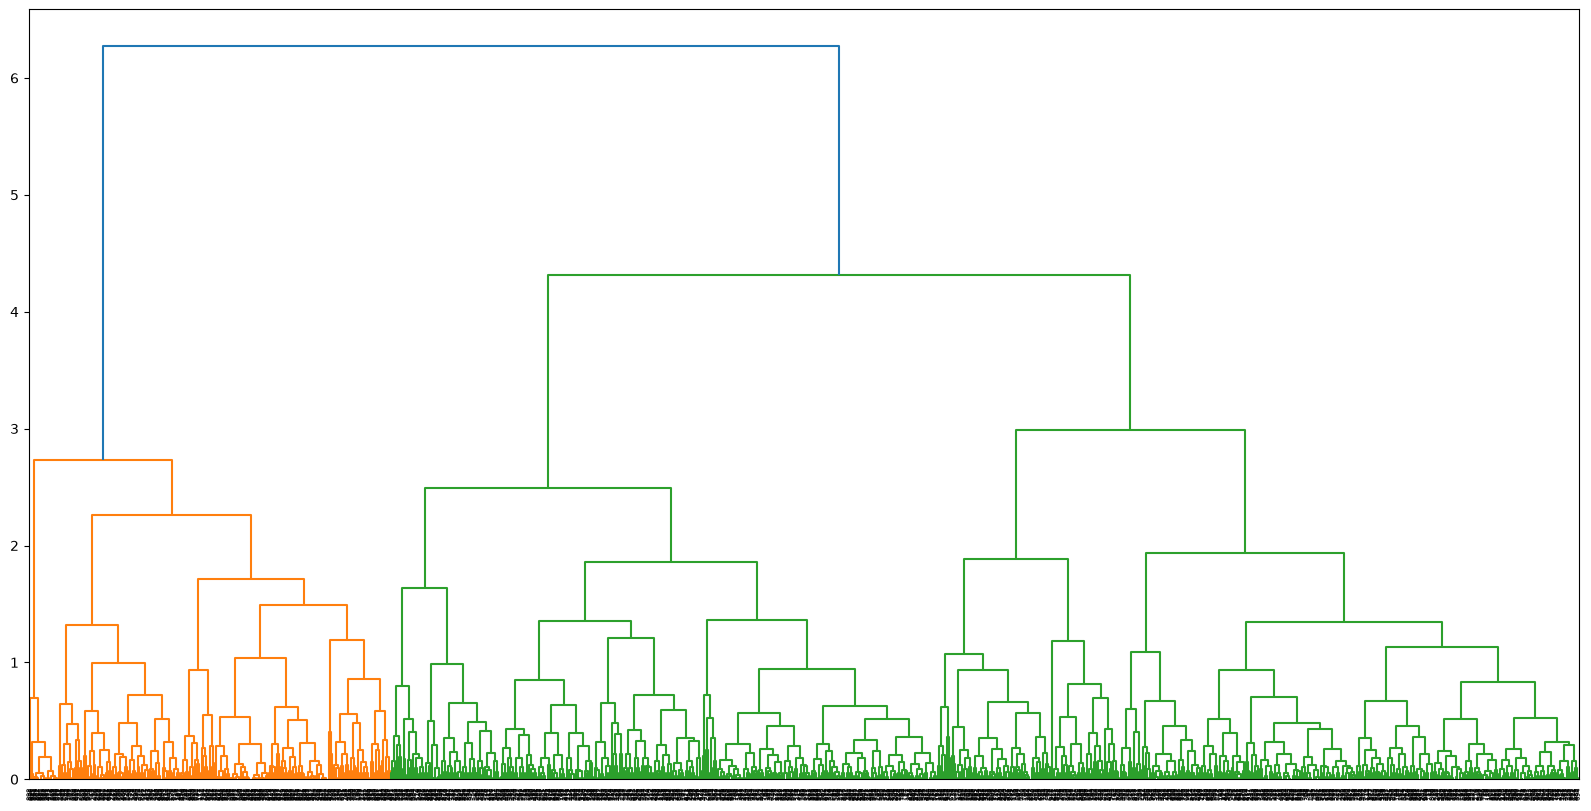

In [13]:

hierar = hierarchy.linkage(data_scaled,'complete')
plt.figure(figsize = (20,10))
dh = hierarchy.dendrogram(hierar)
plt.show()

### **K-MEANS**

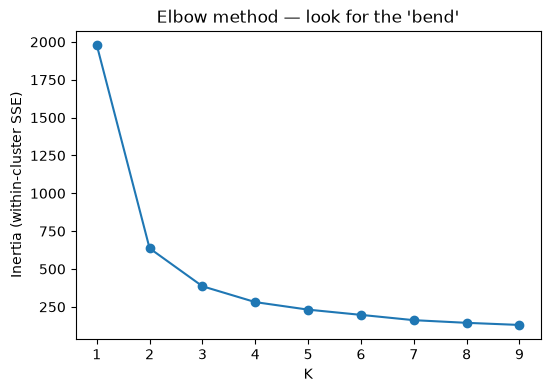

In [14]:
inertias = []
K_range = range(1, 10)
for k in K_range:
    km = KMeans(n_clusters=k, n_init=10, random_state=42)
    km.fit(data_scaled)
    inertias.append(km.inertia_)
plt.figure(figsize=(6, 4))
plt.plot(list(K_range), inertias, marker="o")
plt.xlabel("K"); plt.ylabel("Inertia (within-cluster SSE)")
plt.title("Elbow method — look for the 'bend'")
plt.show()

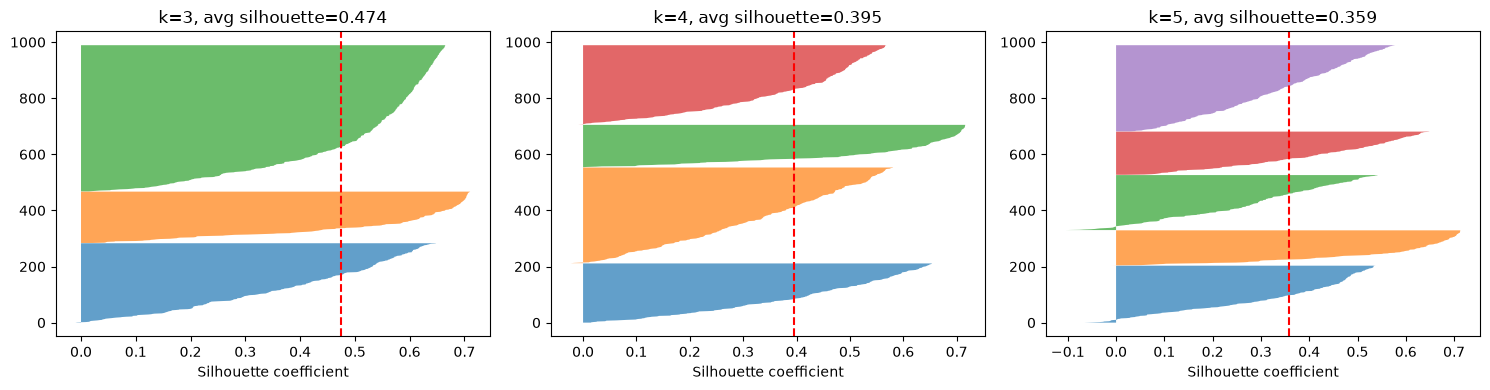

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, k in zip(axes, [3, 4, 5]):
    km = KMeans(n_clusters=k, n_init=10, random_state=42)
    labels = km.fit_predict(data_scaled)
    score = silhouette_score(data_scaled, labels)
    sample_scores = silhouette_samples(data_scaled, labels)

    y_lower = 0
    for i in range(k):
        cluster_scores = np.sort(sample_scores[labels == i])
        y_upper = y_lower + len(cluster_scores)
        ax.fill_betweenx(np.arange(y_lower, y_upper), 0, cluster_scores, alpha=0.7)
        y_lower = y_upper
    ax.axvline(score, color="red", linestyle="--")
    ax.set_title(f"k={k}, avg silhouette={score:.3f}")
    ax.set_xlabel("Silhouette coefficient")
plt.tight_layout()
plt.show()